In [94]:
# ANALYSIS OF INFLUENCE OF PRODUCTION ON THE VALUE OF MANUFACTURING INDUSTRY PRODUCTION IN EAST JAVA PROVINCE

In [3]:
## Importing the relevant libraries

In [5]:
!pip install linearmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## FRAMEWORKS

In [102]:
## Ln(Y)_it=β_1+β_2 Ln(local inv)_it+β_3 Ln(inter inv)_it+β_4 Ln(edu)_it+β_5Lnl(aborforce)_it+e_it
### Based on Production Function, where Y = K L; investation is proxies of K(Capital) (Dornbusch:2018)

In [7]:
## LOAD DATA

In [44]:
excel_file = "Production in East Java.xlsx" 
def load_panel_data(excel_file, sheet_name=0):
# Read Excel file
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
# Display data info
    print("=" * 80)
    print("DATA OVERVIEW")
    print("=" * 80)
    print(f"\nData shape: {df.shape}")
    print(f"\nFirst few rows:\n{df.head()}")
    print(f"\nData types:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nBasic statistics:\n{df.describe()}")
    
    return df
def prepare_panel_data(df, city_col='City', year_col='Year'):
# Set multi-index (entity, time)
    df_panel = df.set_index([city_col, year_col])
    return df_panel

In [46]:
## Panel Data Models

In [48]:
def fit_pooled_ols(df_panel, y, independent_vars):
    y = df_panel[y]
    X = df_panel[independent_vars]
    
    model = PooledOLS(y, X)
    results = model.fit()
    
    return results

In [52]:
def fit_fixed_effects(df_panel, dependent_var, independent_vars):
    y = df_panel[dependent_var]
    X = df_panel[independent_vars]
    
    # Fixed Effects (entity_effects=True removes entity-specific intercepts)
    model = PanelOLS(y, X, entity_effects=True)
    results = model.fit()
    
    return results

In [92]:
def fit_random_effects(df_panel, dependent_var, independent_vars):
    y = df_panel[dependent_var]
    X = df_panel[independent_vars]
    
    # Random Effects model
    model = RandomEffects(y, X)
    results = model.fit()
    
    return results

In [62]:
## MODEL DIAGNOSTICS AND TESTS

In [90]:
def hausman_test(fe_results, re_results):
    # Get coefficients
    fe_coefs = fe_results.params
    re_coefs = re_results.params
    
    # Get covariance matrices
    fe_cov = fe_results.cov
    re_cov = re_results.cov
    
    # Common variables
    common_vars = fe_coefs.index.intersection(re_coefs.index)
    
    # Difference in coefficients
    coef_diff = fe_coefs[common_vars] - re_coefs[common_vars]
    
    # Variance of difference
    var_diff = fe_cov.loc[common_vars, common_vars] - re_cov.loc[common_vars, common_vars]
    
    # Hausman test statistic
    try:
        H = coef_diff.T @ np.linalg.inv(var_diff) @ coef_diff
        p_value = 1 - stats.chi2.cdf(H, df=len(common_vars))
    except:
        H = np.nan
        p_value = np.nan
    
    return H, p_value

In [66]:
def print_hausman_test(H, p_value):
    """Print Hausman test results with interpretation"""
    print("\n" + "=" * 80)
    print("HAUSMAN TEST: Fixed Effects vs Random Effects")
    print("=" * 80)
    print(f"H-statistic: {H:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("\nInterpretation:")
    if p_value < 0.05:
        print("✓ P-value < 0.05: REJECT null hypothesis")
        print("  → Use FIXED EFFECTS model (entities are correlated with regressors)")
    else:
        print("✗ P-value >= 0.05: FAIL TO REJECT null hypothesis")
        print("  → Use RANDOM EFFECTS model (entities are uncorrelated with regressors)")
    print("=" * 80)


In [64]:
def print_model_comparison(pols_results, fe_results, re_results):
    """
    Print comparison of all three models
    """
    print("\n" + "=" * 80)
    print("MODEL COMPARISON: Pooled OLS vs Fixed Effects vs Random Effects")
    print("=" * 80)
    
    # Create comparison table
    comparison_dict = {
        'Pooled OLS': pols_results,
        'Fixed Effects': fe_results,
        'Random Effects': re_results
    }
    
    comparison = compare(comparison_dict)
    print(comparison)
    print("=" * 80)



In [ ]:
## Result Summary

In [70]:
def print_detailed_results(results, model_name):
    """Print detailed results for each model"""
    print("\n" + "=" * 80)
    print(f"{model_name.upper()}")
    print("=" * 80)
    print(results)
    print("=" * 80)

In [ ]:
## Visualisation

In [72]:
def plot_coefficients(pols_results, fe_results, re_results, independent_vars):
    """
    Plot coefficient comparison across models
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get coefficients
    x = np.arange(len(independent_vars))
    width = 0.25
    
    pols_coefs = pols_results.params[independent_vars].values
    fe_coefs = fe_results.params[independent_vars].values
    re_coefs = re_results.params[independent_vars].values
    
    ax.bar(x - width, pols_coefs, width, label='Pooled OLS', alpha=0.8)
    ax.bar(x, fe_coefs, width, label='Fixed Effects', alpha=0.8)
    ax.bar(x + width, re_coefs, width, label='Random Effects', alpha=0.8)
    
    ax.set_xlabel('Variables', fontsize=12, fontweight='bold')
    ax.set_ylabel('Coefficient Values', fontsize=12, fontweight='bold')
    ax.set_title('Production Function Coefficients: Model Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(independent_vars)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✓ Coefficient comparison plot saved: model_comparison.png")
    plt.show()

In [74]:
## Main Execution


PANEL DATA ANALYSIS: PRODUCTION FUNCTION
Cities × Years (Annual Data)

[1/5] Loading data...
DATA OVERVIEW

Data shape: (152, 7)

First few rows:
          city  year         Y  local inv  inter inv  laborforce       edu
0      Pacitan  2017  5.284039   0.000000    0.00000    8.036897  1.948763
1     Ponorogo  2017  6.954993  11.189072    0.00000    7.530480  1.947338
2   Trenggalek  2017  6.188227  11.189072    0.00000    7.406103  1.974081
3  Tulungagung  2017  7.746931   0.000000   -2.52826    9.258273  2.056685
4       Blitar  2017  7.424191  12.282955    0.00000    8.332068  1.982380

Data types:
city           object
year            int64
Y             float64
local inv     float64
inter inv     float64
laborforce    float64
edu           float64
dtype: object

Missing values:
city          0
year          0
Y             0
local inv     0
inter inv     0
laborforce    0
edu           0
dtype: int64

Basic statistics:
             year           Y   local inv   inter inv  laborf

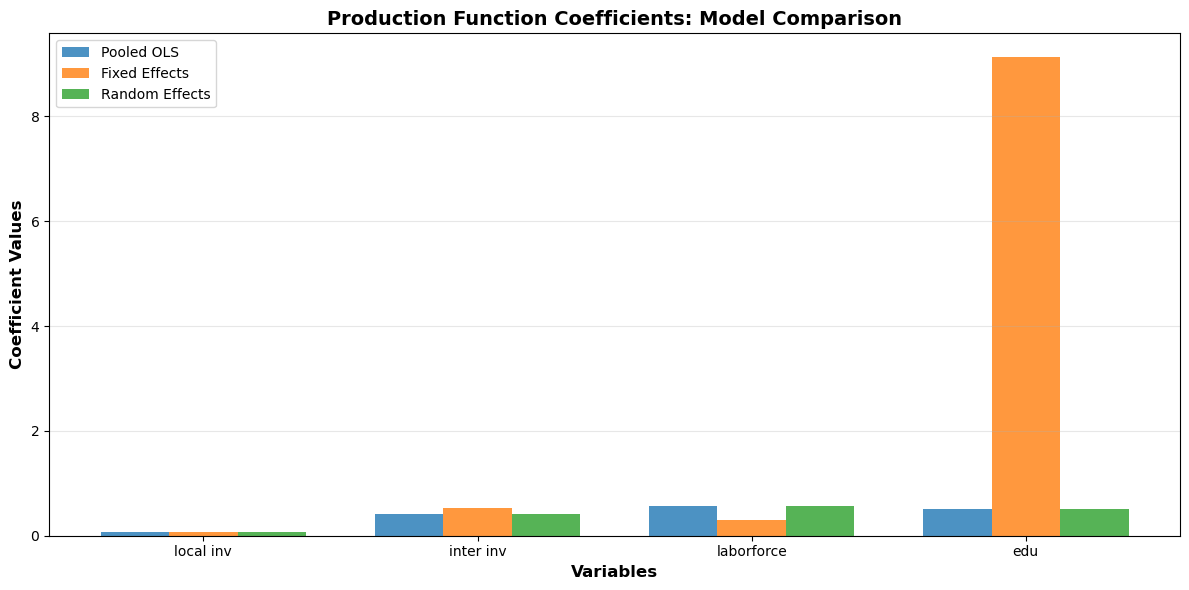


ANALYSIS COMPLETE!


In [88]:
def main(excel_file, sheet_name=0, city_col='city', year_col='year', 
         dependent_var='Y', independent_vars=['local inv', 'inter inv', 'laborforce','edu']): 
    print("\n" + "=" * 80)
    print("PANEL DATA ANALYSIS: PRODUCTION FUNCTION")
    print("Cities × Years (Annual Data)")
    print("=" * 80)
    
    # Step 1: Load and prepare data
    print("\n[1/5] Loading data...")
    df = load_panel_data(excel_file, sheet_name)
    
    print("\n[2/5] Preparing panel data...")
    df_panel = prepare_panel_data(df, city_col, year_col)
    
    # Step 2: Fit models
    print("\n[3/5] Fitting models...")
    print("  • Pooled OLS...")
    pols_results = fit_pooled_ols(df_panel, dependent_var, independent_vars)
    
    print("  • Fixed Effects...")
    fe_results = fit_fixed_effects(df_panel, dependent_var, independent_vars)
    
    print("  • Random Effects...")
    re_results = fit_random_effects(df_panel, dependent_var, independent_vars)
    
    # Step 3: Model comparison and tests
    print("\n[4/5] Model comparison and tests...")
    print_model_comparison(pols_results, fe_results, re_results)
    
    # Hausman test
    H, p_value = hausman_test(fe_results, re_results)
    print_hausman_test(H, p_value)
    
    # Step 4: Detailed results
    print("\n[5/5] Detailed results...")
    print_detailed_results(pols_results, "Pooled OLS Results")
    print_detailed_results(fe_results, "Fixed Effects Results")
    print_detailed_results(re_results, "Random Effects Results")
    
    # Step 5: Visualization
    print("\nGenerating visualizations...")
    plot_coefficients(pols_results, fe_results, re_results, independent_vars)
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE!")
    print("=" * 80)
    
    return {
        'pooled_ols': pols_results,
        'fixed_effects': fe_results,
        'random_effects': re_results,
        'hausman_test': (H, p_value),
        'data': df_panel
    }


if __name__ == "__main__":
    # UPDATE THIS PATH TO YOUR EXCEL FILE
    excel_file = "Production in East Java.xlsx"  # Change this to your actual file path
    
    # Run analysis
    results = main(
        excel_file=excel_file,
        sheet_name=0,
        city_col='city',      # Adjust if your column name is different
        year_col='year',      # Adjust if your column name is different
        dependent_var='Y',  # Adjust to your dependent variable
        independent_vars=['local inv', 'inter inv', 'laborforce', 'edu']
    )

In [ ]:
## Conclusion: according to the results, PLS or REM is suitable to use as an analysis. 
## On the Stata version, PLS is the most suitable to use as representation
## This Cata Panel Analysis is exclude to classic assumption (Normal distrobtion, vif, hettest, autocorrelation)
## On the Stata version atleast has an autocorrelation and solved with transform to robusted
## Treats all observations equally, ignoring panel structure

In [ ]:
# Economic conclusion: 
## as based on Production Function formula, investment and labor force are INFLUENCED by the portion of Production Income
## Some cities in East Java, such as Gresik, Surabaya, and Pasuruan, share large portion of Production Income